In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn

In [2]:
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_selection import f_regression

In [3]:
from vaccination_functions import *
from acs_data_functions import *

In [4]:
tx_mmr_vac_rates = pd.read_csv("../TX_MMR_vax_rate_24_25.csv")
tx_mmr_vac_rates.head()

,Facility Number,School Type,School District or Name,Facility Address,County,MMR Vaccination Rate,Age Group
0,9057829000,Public School,A+ ACADEMY,"8225 BRUTON RD, DALLAS, TX, .",Dallas,96.77,Kindergarten
1,9109901000,Public School,ABBOTT ISD,"P O BOX 226, ABBOTT, TX, .",Hill,95.24,Kindergarten
2,9095901000,Public School,ABERNATHY ISD,"505 7TH ST, ABERNATHY, TX, .",Hale,93.22,Kindergarten
3,9221901000,Public School,ABILENE ISD,"P O BOX 981, ABILENE, TX, .",Taylor,97.76,Kindergarten
4,9014901000,Public School,ACADEMY ISD,"704 E MAIN ST, LITTLE RIVER, TX, .",Bell,98.04,Kindergarten


In [5]:
np.min(tx_mmr_vac_rates['MMR Vaccination Rate'])

np.float64(5.26)

(array([  5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,
         70,  75,  80,  85,  90,  95, 100]),
 [Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60'),
  Text(65, 0, '65'),
  Text(70, 0, '70'),
  Text(75, 0, '75'),
  Text(80, 0, '80'),
  Text(85, 0, '85'),
  Text(90, 0, '90'),
  Text(95, 0, '95'),
  Text(100, 0, '100')])

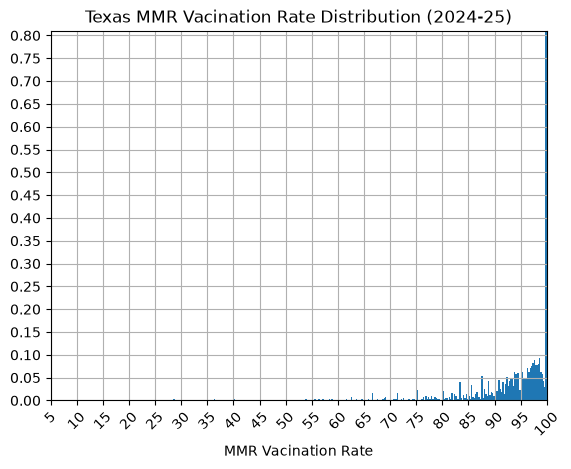

In [6]:
plt.hist(tx_mmr_vac_rates['MMR Vaccination Rate'], bins=380, range=(5, 100), density=True)
#plt.hist(tx_mmr_vac_rates['MMR Vaccination Rate'], bins=380, range=(5, 100))
plt.xlabel('MMR Vacination Rate')
plt.title('Texas MMR Vacination Rate Distribution (2024-25)')
plt.grid()

#plt.ylim(0, 1.21)
plt.ylim(0, 0.81)
#plt.ylim(0, 0.11)
#custom_y_ticks = np.arange(0, 1001, 100)
#custom_y_ticks = np.arange(0.0, 1.2, 0.05)
custom_y_ticks = np.arange(0.0, 0.81, 0.05)
#custom_y_ticks = np.arange(0.0, 0.12, 0.01)
plt.yticks(custom_y_ticks)
#plt.yticks(rotation=45)

plt.xlim(5, 100)
#plt.xlim(50, 100)
#plt.xlim(0, 75)
custom_x_ticks = np.arange(5, 101, 5)
#custom_x_ticks = np.arange(50, 101, 2.5)
#custom_x_ticks = np.arange(50, 99, 2.5)
#custom_x_ticks = np.arange(0, 76, 5)
plt.xticks(custom_x_ticks)
plt.xticks(rotation=45)
#plt.savefig('../plots/tx_mmr_rates_distribution_normalized_24_25.png', bbox_inches="tight")

In [7]:
class_mmr_vac_rates4 = create_MMR_classes(tx_mmr_vac_rates, num_of_classes=4, class_edges=[50.0, 75.0, 87.5])
class_mmr_vac_rates4.head()

,Facility Number,School Type,School District or Name,Facility Address,County,MMR Vaccination Rate,Age Group
0,9057829000,Public School,A+ ACADEMY,"8225 BRUTON RD, DALLAS, TX, .",Dallas,3.0,Kindergarten
1,9109901000,Public School,ABBOTT ISD,"P O BOX 226, ABBOTT, TX, .",Hill,3.0,Kindergarten
2,9095901000,Public School,ABERNATHY ISD,"505 7TH ST, ABERNATHY, TX, .",Hale,3.0,Kindergarten
3,9221901000,Public School,ABILENE ISD,"P O BOX 981, ABILENE, TX, .",Taylor,3.0,Kindergarten
4,9014901000,Public School,ACADEMY ISD,"704 E MAIN ST, LITTLE RIVER, TX, .",Bell,3.0,Kindergarten


In [8]:
class_mmr_vac_rates_high_low = create_MMR_classes(tx_mmr_vac_rates, num_of_classes=2, class_edges=[53.1])
class_mmr_vac_rates_high_low.head()

,Facility Number,School Type,School District or Name,Facility Address,County,MMR Vaccination Rate,Age Group
0,9057829000,Public School,A+ ACADEMY,"8225 BRUTON RD, DALLAS, TX, .",Dallas,1.0,Kindergarten
1,9109901000,Public School,ABBOTT ISD,"P O BOX 226, ABBOTT, TX, .",Hill,1.0,Kindergarten
2,9095901000,Public School,ABERNATHY ISD,"505 7TH ST, ABERNATHY, TX, .",Hale,1.0,Kindergarten
3,9221901000,Public School,ABILENE ISD,"P O BOX 981, ABILENE, TX, .",Taylor,1.0,Kindergarten
4,9014901000,Public School,ACADEMY ISD,"704 E MAIN ST, LITTLE RIVER, TX, .",Bell,1.0,Kindergarten


In [9]:
counties_with_vac = tx_mmr_vac_rates['County'].unique()
#tx_mmr_vac_rates['County'].unique()

In [10]:
acs_data_path = "../acs_data/"

education_df = pd.read_csv(acs_data_path+"tx_county_education_24.csv")
education_var_df = pd.read_csv(acs_data_path+"educationVars_acs.csv")

enrollment_ext_df = pd.read_csv(acs_data_path+"tx_county_enrollment_24_extended.csv")
enrollment_var_ext_df = pd.read_csv(acs_data_path+"enrollmentVars_acs_extended.csv")

disability_df = pd.read_csv(acs_data_path+"tx_county_disability_24.csv")
disability_var_df = pd.read_csv(acs_data_path+"disabilityVars_acs.csv")

health_insurance_df = pd.read_csv(acs_data_path+"tx_county_health_insurance_24.csv")
health_insurance_var_df = pd.read_csv(acs_data_path+"healthInsurVars_acs.csv")

language_df = pd.read_csv(acs_data_path+"tx_county_language_24.csv")
language_var_df = pd.read_csv(acs_data_path+"languageVars_acs.csv")


In [11]:
enroll_concepts = ['B14001_', 'B14002_', 'B14003_', 'B14006_', 'B14007', 'B14007_', 'B14007A_', 'B14007B_', 'B14007C_',
                   'B14007D_', 'B14007E_', 'B14007F_', 'B14007G_', 'B14007H_', 'B14007I_',]

enroll_df_dict = {}

for c in enroll_concepts:
    enroll_sub_df = enrollment_ext_df[enrollment_ext_df['variable'].str.contains(c)]
    enroll_df_dict[c] = enroll_sub_df

In [12]:
enroll_totals_df = enroll_df_dict['B14001_']
enroll_gender_grade_df = enroll_df_dict['B14002_']
enroll_gender_type_age_df = enroll_df_dict['B14003_']
enroll_poverty_df = enroll_df_dict['B14006_']
enroll_detailed_grade_race_df = enroll_df_dict['B14007']
enroll_detailed_grade_all_df = enroll_df_dict['B14007_']

In [13]:
edu_concepts = ['B15001_', 'B15003_']
edu_df_dict = {}
for c in edu_concepts:
    edu_sub_df = education_df[education_df['variable'].str.contains(c)]
    edu_df_dict[c] = edu_sub_df

In [14]:
edu_totals_df = edu_df_dict['B15001_']
edu_total_by_level_df = edu_df_dict['B15003_']

In [15]:
education_total_with_var_all, education_total_with_var_no_gender = create_predictor_datasets(edu_totals_df, education_var_df, counties_with_vac)
education_total_level_with_var_all, education_total_level_with_var_no_gender = create_predictor_datasets(edu_total_by_level_df, education_var_df, counties_with_vac)

In [16]:
education_total_with_var_all.columns

Index(['Estimate_Total_Female_18_24_9th_12th_grade,_no_diploma_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Associate's_degree_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Bachelor's_degree_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Graduate_or_professional_degree_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_High_school_graduate_(includes_equivalency)_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Less_than_9th_grade_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Some_college,_no_deg

In [17]:
#education_total_level_with_var_all.columns
edu_attainment_percent = pd.DataFrame()

for col in education_total_level_with_var_all.drop(columns='Estimate_Total_Educational_Attainment_for_the_Population_25_Years_and_Over').columns:
    edu_attainment_percent['Percent_'+col] = education_total_level_with_var_all[col]/education_total_level_with_var_all['Estimate_Total_Educational_Attainment_for_the_Population_25_Years_and_Over']

edu_attainment_percent.columns = edu_attainment_percent.columns.str.replace({'_Estimate_Total_': '_', '_for_the_Population_':'_'}, regex=True)

In [18]:
edu_attainment_percent.columns

Index(['Percent_10th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_11th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_12th_grade,_no_diploma_Educational_Attainment_25_Years_and_Over',
       'Percent_1st_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_2nd_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_3rd_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_4th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_5th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_6th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_7th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_8th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_9th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_Associate's_degree_Educational_Attainment_25_Years_and_Over',
       'Percent_Bachelor's_degree_Educational_Attainment_25_Years_and_Over',
  

In [19]:
disability_with_var_all, disability_with_var_no_gender = create_predictor_datasets(disability_df, disability_var_df, counties_with_vac)
language_with_var_all, language_with_var_no_gender = create_predictor_datasets(language_df, language_var_df, counties_with_vac)
health_insurance_with_var_all, health_insurance_with_var_no_gender = create_predictor_datasets(health_insurance_df, health_insurance_var_df, counties_with_vac)
education_with_var_all, education_with_var_no_gender = create_predictor_datasets(education_df, education_var_df, counties_with_vac)

In [20]:
disability_with_var_all.columns = disability_with_var_all.columns.str.replace({'_Sex_by_Age_by_Disability_Status': ''}, regex=True)
health_insurance_with_var_all.columns = health_insurance_with_var_all.columns.str.replace({'_Health_Insurance_Coverage_Status_by_Sex_by_Age': ''}, regex=True)
language_with_var_all.columns = language_with_var_all.columns.str.replace({'_Detailed_Household_Language_by_Household_Limited_English_Speaking_Status': ''}, regex=True)

In [21]:
disability_percent = pd.DataFrame()
disability_total = disability_with_var_all['Estimate_Total']

disability_percent['Percent_Under_5_with_disability'] = (disability_with_var_all['Estimate_Total_Male_Under_5_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_Under_5_With_a_disability'])/disability_total
disability_percent['Percent_Under_5_no_disability'] = (disability_with_var_all['Estimate_Total_Male_Under_5_No_disability']+ disability_with_var_all['Estimate_Total_Female_Under_5_No_disability'])/disability_total
disability_percent['Percent_5_17_with_disability'] = (disability_with_var_all['Estimate_Total_Male_5_17_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_5_17_With_a_disability'])/disability_total
disability_percent['Percent_5_17_no_disability'] = (disability_with_var_all['Estimate_Total_Male_5_17_No_disability']+ disability_with_var_all['Estimate_Total_Female_5_17_No_disability'])/disability_total
disability_percent['Percent_18_34_with_disability'] = (disability_with_var_all['Estimate_Total_Male_18_34_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_18_34_With_a_disability'])/disability_total
disability_percent['Percent_18_34_no_disability'] = (disability_with_var_all['Estimate_Total_Male_18_34_No_disability']+ disability_with_var_all['Estimate_Total_Female_18_34_No_disability'])/disability_total
disability_percent['Percent_35_64_with_disability'] = (disability_with_var_all['Estimate_Total_Male_35_64_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_35_64_With_a_disability'])/disability_total
disability_percent['Percent_35_64_no_disability'] = (disability_with_var_all['Estimate_Total_Male_35_64_No_disability']+ disability_with_var_all['Estimate_Total_Female_35_64_No_disability'])/disability_total
disability_percent['Percent_65_74_with_disability'] = (disability_with_var_all['Estimate_Total_Male_65_74_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_65_74_With_a_disability'])/disability_total
disability_percent['Percent_65_74_no_disability'] = (disability_with_var_all['Estimate_Total_Male_65_74_No_disability']+ disability_with_var_all['Estimate_Total_Female_65_74_No_disability'])/disability_total
disability_percent['Percent_75_and_over_with_disability'] = (disability_with_var_all['Estimate_Total_Male_75_and_over_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_75_and_over_With_a_disability'])/disability_total
disability_percent['Percent_75_and_over_no_disability'] = (disability_with_var_all['Estimate_Total_Male_75_and_over_No_disability']+ disability_with_var_all['Estimate_Total_Female_75_and_over_No_disability'])/disability_total


In [22]:
health_insurance_percent = pd.DataFrame()
health_insurance_total = health_insurance_with_var_all['Estimate_Total']

health_insurance_percent['Percent_Under_6_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_Under_6_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_Under_6_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_Under_6_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_Under_6_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_Under_6_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_6_18_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_6_18_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_6_18_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_6_18_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_6_18_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_6_18_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_19_25_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_19_25_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_19_25_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_19_25_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_19_25_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_19_25_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_26_34_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_26_34_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_26_34_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_26_34_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_26_34_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_26_34_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_35_44_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_35_44_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_35_44_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_35_44_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_35_44_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_35_44_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_45_54_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_45_54_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_45_54_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_45_54_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_45_54_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_45_54_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_55_64_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_55_64_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_55_64_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_55_64_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_55_64_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_55_64_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_65_74_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_65_74_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_65_74_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_65_74_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_65_74_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_65_74_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_75_and_over_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_75_and_over_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_75_and_over_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_75_and_over_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_75_and_over_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_75_and_over_No_health_insurance_coverage'])/health_insurance_total

In [23]:
language_percent = pd.DataFrame()
language_total = language_with_var_all['Estimate_Total']

language_percent['Percent_Limited_English_speaking_household'] = (language_with_var_all['Estimate_Total_Vietnamese_Limited_English_speaking_household'] 
                                                                + language_with_var_all['Estimate_Total_Tagalog_(incl._Filipino)_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Spanish_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Russian,_Polish,_or_other_Slavic_languages_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_and_unspecified_languages_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_Indo-European_languages_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_Asian_and_Pacific_Island_languages_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Chinese_(incl._Mandarin,_Cantonese)_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_French,_Haitian,_or_Cajun_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_German_or_other_West_Germanic_languages_Limited_English_speaking_household']    
                                                                + language_with_var_all['Estimate_Total_Arabic_Limited_English_speaking_household']   
                                                                + language_with_var_all['Estimate_Total_Korean_Limited_English_speaking_household'])/language_total

language_percent['Percent_Not_a_limited_English_speaking_household'] = (language_with_var_all['Estimate_Total_Vietnamese_Not_a_limited_English_speaking_household'] 
                                                                + language_with_var_all['Estimate_Total_Tagalog_(incl._Filipino)_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Spanish_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Russian,_Polish,_or_other_Slavic_languages_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_and_unspecified_languages_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_Indo-European_languages_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_Asian_and_Pacific_Island_languages_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Chinese_(incl._Mandarin,_Cantonese)_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_French,_Haitian,_or_Cajun_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_German_or_other_West_Germanic_languages_Not_a_limited_English_speaking_household']    
                                                                + language_with_var_all['Estimate_Total_Arabic_Not_a_limited_English_speaking_household']   
                                                                + language_with_var_all['Estimate_Total_Korean_Not_a_limited_English_speaking_household'])/language_total

language_percent['Percent_English_only_speaking_household'] = language_with_var_all['Estimate_Total_English_only']/language_total

In [24]:
enrollment_gender_grade_with_var_all, enrollment_gender_grade_with_var_no_gender = create_predictor_datasets(enroll_gender_grade_df, enrollment_var_ext_df, counties_with_vac)
enrollment_totals_with_var_all, enrollment_totals_with_var_no_gender = create_predictor_datasets(enroll_totals_df, enrollment_var_ext_df, counties_with_vac)
enrollment_gender_type_age_with_var_all, enrollment_gender_type_age_with_var_no_gender = create_predictor_datasets(enroll_gender_type_age_df, enrollment_var_ext_df, counties_with_vac)
enrollment_poverty_with_var_all, enrollment_poverty_with_var_no_gender = create_predictor_datasets(enroll_poverty_df, enrollment_var_ext_df, counties_with_vac)
enrollment_grade_race_with_var_all, enrollment_grade_race_with_var_no_gender = create_predictor_datasets(enroll_detailed_grade_race_df, enrollment_var_ext_df, counties_with_vac)

In [25]:
enrollment_totals_with_var_all.columns = enrollment_totals_with_var_all.columns.str.replace({'_School_Enrollment_by_Level_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_gender_grade_with_var_all.columns = enrollment_gender_grade_with_var_all.columns.str.replace({'_Sex_by_School_Enrollment_by_Level_of_School_by_Type_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_gender_type_age_with_var_all.columns = enrollment_gender_type_age_with_var_all.columns.str.replace({'_Sex_by_School_Enrollment_by_Type_of_School_by_Age_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_poverty_with_var_all.columns = enrollment_poverty_with_var_all.columns.str.replace({'_in_the_Past_12_Months_by_School_Enrollment_by_Level_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_grade_race_with_var_all.columns = enrollment_grade_race_with_var_all.columns.str.replace({'_by_Detailed_Level_of_School_for_the_Population_': '_'}, regex=True)

In [26]:
total_enrolled_grade_schoolType = enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_School_Enrollment_3_Years_and_Over'] + enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollment_by_grade_schoolType_percent = pd.DataFrame()

enrollment_by_grade_schoolType_percent['Percent_Undergraduate_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_college_undergraduate_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_college_undergraduate_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Undergraduate_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_college_undergraduate_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_college_undergraduate_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_1_4_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_1_4_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_5_8_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_5_8_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_9_12_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_9_12_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Graduate_Professional_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Graduate_Professional_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Kindergarten_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_kindergarten_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_kindergarten_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Kindergarten_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_kindergarten_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_kindergarten_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Nursery_Preschool_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Nursery_Preschool_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType

enrollment_by_grade_schoolType_percent['Percent_Private'] = enrollment_by_grade_schoolType_percent['Percent_Undergraduate_Private'] + enrollment_by_grade_schoolType_percent['Percent_grade_1_4_Private'] + enrollment_by_grade_schoolType_percent['Percent_grade_5_8_Private'] + enrollment_by_grade_schoolType_percent['Percent_grade_9_12_Private'] + enrollment_by_grade_schoolType_percent['Percent_Graduate_Professional_Private'] + enrollment_by_grade_schoolType_percent['Percent_Kindergarten_Private'] + enrollment_by_grade_schoolType_percent['Percent_Nursery_Preschool_Private']
enrollment_by_grade_schoolType_percent['Percent_Public'] = enrollment_by_grade_schoolType_percent['Percent_Undergraduate_Public'] + enrollment_by_grade_schoolType_percent['Percent_grade_1_4_Public'] + enrollment_by_grade_schoolType_percent['Percent_grade_5_8_Public'] + enrollment_by_grade_schoolType_percent['Percent_grade_9_12_Public'] + enrollment_by_grade_schoolType_percent['Percent_Graduate_Professional_Public'] + enrollment_by_grade_schoolType_percent['Percent_Kindergarten_Public'] + enrollment_by_grade_schoolType_percent['Percent_Nursery_Preschool_Public']

In [27]:
#enrollment_totals_with_var_all.columns

enrollemnt_by_grade_percent = pd.DataFrame()

enrollemnt_by_grade_percent['Percent_Not_Enrolled'] = enrollment_totals_with_var_all['Estimate_Total_Not_enrolled_in_school_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_Undergraduate'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_college,_undergraduate_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_grade_1_4'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_grade_1_grade_4_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_grade_5_8'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_grade_5_grade_8_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_grade_9_12'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_grade_9_grade_12_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_Kindergarten'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_kindergarten_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_Nursery_Preschool'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_Graduate_Professional'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Graduate_or_professional_school_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']


In [28]:
#enrollment_poverty_with_var_all.columns
enrollment_poverty_percent = pd.DataFrame()

enrollment_poverty_percent['Percent_Above_Poverty_Undergraduate_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_college_undergraduate_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_grade_1_4_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_grade_5_8_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_grade_9_12_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Graduate_Professional_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Kindergarten_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_kindergarten_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Nursery_Preschool_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Enrolled_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Not_Enrolled_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Not_enrolled_in_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']

enrollment_poverty_percent['Percent_Below_Poverty_Undergraduate_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_college_undergraduate_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_grade_1_4_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_grade_5_8_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_grade_9_12_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Graduate_Professional_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Kindergarten_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_kindergarten_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Nursery_Preschool_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Enrolled_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Not_Enrolled_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Not_enrolled_in_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']

In [29]:
enrollment_grade_race_percent = pd.DataFrame()
total_enrolled_grade_race = enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over']
enrollment_grade_race_percent['Percent_School_Enrollment_American_Indian_and_Alaska_Native_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(American_Indian_and_Alaska_Native_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Asian_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Asian_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Black_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Black_or_African_American_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Hispanic_or_Latino'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Hispanic_or_Latino)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Native_Hawaiian_and_Other_Pacific_Islander_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Native_Hawaiian_and_Other_Pacific_Islander_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Some_Other_Race_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Some_Other_Race_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Two_or_More_Races'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Two_or_More_Races)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_White_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(White_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_White_Alone_Not_Hispanic_or_Latino'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(White_Alone,_Not_Hispanic_or_Latino)']/total_enrolled_grade_race


In [30]:
high_school_df, middle_school_df, elementary_school_df = seperate_level_of_school_enrollment(enrollment_grade_race_with_var_all)

In [31]:
calculate_race_percents_by_school_level_enrollment(high_school_df, enrollment_grade_race_percent, school_level="high")
calculate_race_percents_by_school_level_enrollment(middle_school_df, enrollment_grade_race_percent, school_level="middle")
calculate_race_percents_by_school_level_enrollment(elementary_school_df, enrollment_grade_race_percent, school_level="elementary")

In [32]:
enrollment_percent_df_list = [enrollment_grade_race_percent, enrollment_poverty_percent, enrollemnt_by_grade_percent, enrollment_by_grade_schoolType_percent]
all_enrollment_percent = combine_acs_variables(enrollment_percent_df_list)
all_vac_enrollment_percent_regression = vac_predictor_merge(tx_mmr_vac_rates, all_enrollment_percent)
all_vac_enrollment_percent_regression.to_csv("../feature_inputs/acs_enrollment_percent_regression.csv", index=False)
#all_vac_enrollment_percent_class6 = vac_predictor_merge(class_mmr_vac_rates, all_enrollment_percent)
all_vac_enrollment_percent_class_high_low = vac_predictor_merge(class_mmr_vac_rates_high_low, all_enrollment_percent)
all_vac_enrollment_percent_class_high_low.to_csv("../feature_inputs/acs_enrollment_percent_biClass_53p1_percent.csv", index=False)

In [33]:
enroll_edu_percent_df_list = [enrollment_grade_race_percent, enrollment_poverty_percent, enrollemnt_by_grade_percent, enrollment_by_grade_schoolType_percent, edu_attainment_percent]
all_enroll_edu_percent = combine_acs_variables(enroll_edu_percent_df_list)
all_vac_enroll_edu_percent_regression = vac_predictor_merge(tx_mmr_vac_rates, all_enroll_edu_percent)
all_vac_enroll_edu_percent_regression.to_csv("../feature_inputs/acs_enroll_education_percent_regression.csv", index=False)
#all_vac_enroll_edu_percent_class = vac_predictor_merge(class_mmr_vac_rates, all_enroll_edu_percent)
all_vac_enroll_edu_percent_class_high_low = vac_predictor_merge(class_mmr_vac_rates_high_low, all_enroll_edu_percent)
all_vac_enroll_edu_percent_class_high_low.to_csv("../feature_inputs/acs_enroll_edu_percent_biClass_53p1_percent.csv", index=False)

In [34]:
enroll_edu_dis_lang_insur_percent_df_list = (enroll_edu_percent_df_list + [disability_percent, language_percent, health_insurance_percent])
all_enroll_edu_dis_lang_insur_percent = combine_acs_variables(enroll_edu_dis_lang_insur_percent_df_list)
all_vac_enroll_edu_dis_lang_insur_percent_regression = vac_predictor_merge(tx_mmr_vac_rates, all_enroll_edu_percent)
all_vac_enroll_edu_dis_lang_insur_percent_regression.to_csv("../feature_inputs/acs_enroll_edu_lang_insurance_percent_regression.csv", index=False)
all_vac_enroll_edu_dis_lang_insur_percent_class_high_low = vac_predictor_merge(class_mmr_vac_rates_high_low, all_enroll_edu_percent)
all_vac_enroll_edu_dis_lang_insur_percent_class_high_low.to_csv("../feature_inputs/acs_enroll_edu_lang_insurance_percent_biClass_53p1_percent.csv", index=False)

c:\Users\19037\Documents\Measels_Vaccination\code_backup\acs_data_functions.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_acs_variables_ii = pd.merge(pd.merge(all_acs_variables_i, df_list[4], on=['County']), pd.merge(df_list[5], df_list[6], on=['County']), on=['County'])
c:\Users\19037\Documents\Measels_Vaccination\code_backup\acs_data_functions.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_acs_variables = pd.merge(all_acs_variables_ii, df_list[7], on=['County'])


In [35]:
all_vac_enrollment_percent_class_high_low = vac_predictor_merge(class_mmr_vac_rates_high_low, all_enrollment_percent)
all_vac_enroll_edu_percent_class_high_low = vac_predictor_merge(class_mmr_vac_rates_high_low, all_enroll_edu_percent)
#all_vac_enroll_edu_percent_class_high_low = vac_predictor_merge(class_mmr_vac_rates_high_low, all_enroll_edu_percent)